In [1]:
import pandas as pd 

import matplotlib.pyplot as plt 

import seaborn as sns 

from sklearn.model_selection import train_test_split 

from sklearn.linear_model import LinearRegression 

In [2]:
df = pd.read_excel("2025 County Health Rankings Data.xlsx", sheet_name="Select Measure Data") 

df.head()

,FIPS,State,County,Average Number of Physically Unhealthy Days,% Fair or Poor Health,Average Number of Mentally Unhealthy Days,% Uninsured,Primary Care Physicians Ratio,Mental Health Provider Ratio,Food Environment Index,% Some College,% Completed High School,% Unemployed,80th Percentile Income,% Severe Housing Problems
0,1000,Alabama,NaN,4.073055,21.8,5.766892,10.488727,1571:1,684:1,5.3,61.772770,88.128041,2.498243,126785.0,13.082342
1,1001,Alabama,Autauga,4.300364,17.7,5.832901,8.190361,2273:1,2743:1,6.8,61.378732,90.278902,2.188889,132562.0,13.520933
2,1003,Alabama,Baldwin,3.876436,17.0,6.020778,10.212342,1595:1,828:1,7.4,64.847875,91.731400,2.279497,141920.0,11.968116
3,1005,Alabama,Barbour,5.431030,28.4,6.339986,12.117042,2496:1,3512:1,6.2,44.077431,77.813705,4.431017,99138.0,13.806381
4,1007,Alabama,Bibb,5.055619,25.1,6.565945,10.835799,1498:1,2734:1,7.3,43.533225,80.340217,2.462380,102593.0,11.926606


In [3]:
model_df = df[[ 

    "Average Number of Mentally Unhealthy Days", 

    "% Some College", 

    "% Completed High School", 

    "80th Percentile Income", 

    "% Unemployed", 

    "% Severe Housing Problems", 

    "Food Environment Index" 

]] 

model_df.head() 

,Average Number of Mentally Unhealthy Days,% Some College,% Completed High School,80th Percentile Income,% Unemployed,% Severe Housing Problems,Food Environment Index
0,5.766892,61.772770,88.128041,126785.0,2.498243,13.082342,5.3
1,5.832901,61.378732,90.278902,132562.0,2.188889,13.520933,6.8
2,6.020778,64.847875,91.731400,141920.0,2.279497,11.968116,7.4
3,6.339986,44.077431,77.813705,99138.0,4.431017,13.806381,6.2
4,6.565945,43.533225,80.340217,102593.0,2.462380,11.926606,7.3


In [4]:
model_df.isna().sum() 

model_df = model_df.dropna() 

In [5]:
model_df.isna().sum() 

Average Number of Mentally Unhealthy Days    0
% Some College                               0
% Completed High School                      0
80th Percentile Income                       0
% Unemployed                                 0
% Severe Housing Problems                    0
Food Environment Index                       0
dtype: int64

In [6]:
y = model_df["Average Number of Mentally Unhealthy Days"]

In [7]:
X = model_df[[ 

    "% Some College", 

    "% Completed High School", 

    "80th Percentile Income", 

    "% Unemployed", 

    "% Severe Housing Problems", 

    "Food Environment Index" 

]] 

In [8]:
print(y.head()) 

print() 

print(X.head()) 

0    5.766892
1    5.832901
2    6.020778
3    6.339986
4    6.565945
Name: Average Number of Mentally Unhealthy Days, dtype: float64

   % Some College  % Completed High School  80th Percentile Income  \
0       61.772770                88.128041                126785.0   
1       61.378732                90.278902                132562.0   
2       64.847875                91.731400                141920.0   
3       44.077431                77.813705                 99138.0   
4       43.533225                80.340217                102593.0   

   % Unemployed  % Severe Housing Problems  Food Environment Index  
0      2.498243                  13.082342                     5.3  
1      2.188889                  13.520933                     6.8  
2      2.279497                  11.968116                     7.4  
3      4.431017                  13.806381                     6.2  
4      2.462380                  11.926606                     7.3  


In [9]:
X_train, X_test, y_train, y_test = train_test_split( 

    X, y, test_size=0.2, random_state=42 

)

print(X_train.shape) 

print(X_test.shape) 

print(y_train.shape) 

print(y_test.shape) 

(2504, 6)
(626, 6)
(2504,)
(626,)


In [10]:
from sklearn.preprocessing import StandardScaler 

In [12]:
scaler = StandardScaler()

In [13]:
X_train_scaled = scaler.fit_transform(X_train) 

X_test_scaled = scaler.transform(X_test) 

In [14]:
scaled_model = LinearRegression() 

scaled_model.fit(X_train_scaled, y_train) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
print("Training R^2:", scaled_model.score(X_train_scaled, y_train)) 

print("Testing R^2:", scaled_model.score(X_test_scaled, y_test)) 

Training R^2: 0.39936763130367803
Testing R^2: 0.3742849555698846


In [17]:
scaled_coef_df = pd.DataFrame({ 

    "Predictor": X.columns, 

    "Standardized Coefficient": scaled_model.coef_ 

})

scaled_coef_df 

,Predictor,Standardized Coefficient
0,% Some College,-0.239666
1,% Completed High School,0.015995
2,80th Percentile Income,-0.081275
3,% Unemployed,0.114020
4,% Severe Housing Problems,0.015917
5,Food Environment Index,-0.065625


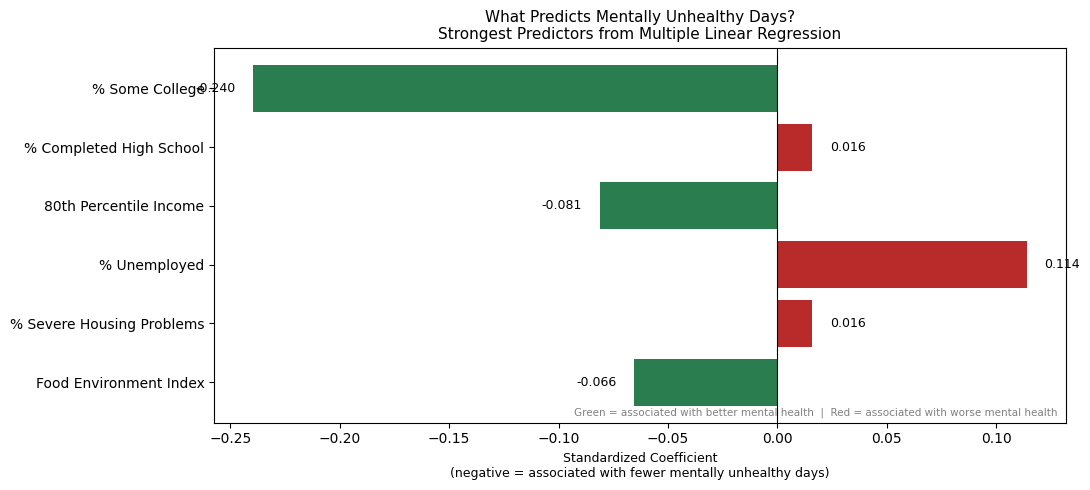

In [1]:
import matplotlib.pyplot as plt

predictors = [
    "% Some College",
    "% Completed High School",
    "80th Percentile Income",
    "% Unemployed",
    "% Severe Housing Problems",
    "Food Environment Index"
]

coefficients = [-0.239666, 0.015995, -0.081275, 0.114020, 0.015917, -0.065625]

colors = ["#2a7d4f" if c < 0 else "#b92a2a" for c in coefficients]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(predictors, coefficients, color=colors)
ax.axvline(0, color="black", linewidth=0.8)

for bar, val in zip(bars, coefficients):
    x = val + 0.008 if val >= 0 else val - 0.008
    ha = "left" if val >= 0 else "right"
    ax.text(x, bar.get_y() + bar.get_height() / 2, f"{val:.3f}",
            va="center", ha=ha, fontsize=9)

ax.set_xlabel("Standardized Coefficient\n(negative = associated with fewer mentally unhealthy days)", fontsize=9)
ax.set_title("What Predicts Mentally Unhealthy Days?\nStrongest Predictors from Multiple Linear Regression", fontsize=11)
ax.invert_yaxis()

ax.text(0.99, 0.02, "Green = associated with better mental health  |  Red = associated with worse mental health",
        transform=ax.transAxes, fontsize=7.5, ha="right", color="gray")

plt.tight_layout()
plt.savefig("mental_unhealthy_days_coefficients.png", dpi=200, bbox_inches="tight")
plt.show()